# Kinesin Motor Proteins — Phylogenetic Analysis

Based on:
- Neher Lab Auspice tutorial (2019): https://neherlab.org/201901_krisp_auspice.html
- pb3lab ibm3202 Lab 03 Phylogenetics

**Workflow:** NCBI fetch → MUSCLE alignment → trim → NJ + FastTree ML → colour-coded figure → download

## Step 1 — Install dependencies

In [1]:
!pip install biopython --quiet
!apt-get install -y muscle fasttree --quiet
# Verify muscle binary name (older apt gives 'muscle', newer may differ)
import subprocess, shutil
MUSCLE_BIN = shutil.which('muscle') or shutil.which('muscle3') or 'muscle'
print('muscle binary:', MUSCLE_BIN)
print('Done')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 41.7 MB/s eta 0:00:00
Reading package lists...
Building dependency tree...
Reading state information...
The following NEW packages will be installed:
  fasttree muscle
0 upgraded, 2 newly installed, 0 to remove and 2 not upgraded.
Need to get 418 kB of archives.
After this operation, 1,207 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 muscle amd64 1:3.8.1551-2build1 [244 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fasttree amd64 2.1.11-2 [174 kB]
Fetched 418 kB in 4s (114 kB/s)
Selecting previously unselected package muscle.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../muscle_1%3a3.8.1551-2build1_amd64.deb ...
Unpacking muscle (1:3.8.1551-2build1) ...
Selecting previously unselected package fasttree.
Preparing to unpack .../fasttree_2.1.11-2_amd64.deb ...
Unpacking fasttree (2.1.11-2) ...
Setting up muscle

## Step 2 — Imports & helper functions

In [2]:
import os, time, subprocess
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from Bio import Entrez, SeqIO, AlignIO
from Bio import Phylo
from Bio.Phylo.TreeConstruction import DistanceCalculator, DistanceTreeConstructor

Entrez.email = 'your_email@example.com'  # <-- CHANGE THIS
print('BioPython', __import__('Bio').__version__, '— all imports OK')

BioPython 1.87 — all imports OK


In [3]:
def run_muscle(in_fasta, out_fasta):
    """Run MUSCLE alignment using subprocess (works with all BioPython versions)."""
    cmd = [MUSCLE_BIN, '-in', in_fasta, '-out', out_fasta]
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        # Newer MUSCLE v5 uses different flags
        cmd = [MUSCLE_BIN, '-align', in_fasta, '-output', out_fasta]
        result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print('MUSCLE stderr:', result.stderr[:500])
        raise RuntimeError('MUSCLE alignment failed')
    return out_fasta

def trim(aln, thr=0.5):
    """Remove alignment columns with > thr gap fraction."""
    n = len(aln)
    keep = [i for i in range(aln.get_alignment_length())
            if aln[:, i].count('-') / n <= thr]
    t = aln[:, keep[0]:keep[0]+1]
    for i in keep[1:]:
        t = t + aln[:, i:i+1]
    return t

def fetch(acc, lbl):
    """Fetch one protein sequence from NCBI."""
    try:
        h = Entrez.efetch(db='protein', id=acc, rettype='fasta', retmode='text')
        r = SeqIO.read(h, 'fasta'); h.close()
        r.id = r.name = lbl
        r.description = f'{lbl}|{acc}'
        time.sleep(0.4)   # respect NCBI rate limit
        return r
    except Exception as e:
        print(f'  FAIL {lbl}: {e}')
        return None

print('Helper functions defined OK')

Helper functions defined OK


## Step 3 — Define sequences (one or two per family)

In [4]:
kinesin_seqs = {
    # Kinesin-1  plus-end axonal transport
    'KIF5A_Hsap_Kin1'  : 'NP_004975',
    'KHC_Dmel_Kin1'    : 'NP_524518',
    # Kinesin-2  intraflagellar transport
    'KIF3A_Hsap_Kin2'  : 'NP_002243',
    'OSM3_Cele_Kin2'   : 'NP_491990',
    # Kinesin-3  fast vesicle transport
    'KIF1A_Hsap_Kin3'  : 'NP_006550',
    'UNC104_Cele_Kin3' : 'NP_001255892',
    # Kinesin-4  DNA-associated
    'KIF4A_Hsap_Kin4'  : 'NP_002253',
    # Kinesin-5  bipolar spindle
    'KIF11_Hsap_Kin5'  : 'NP_004514',
    'CIN8_Scer_Kin5'   : 'NP_014861',
    # Kinesin-6  cytokinesis
    'KIF20A_Hsap_Kin6' : 'NP_005550',
    # Kinesin-7  kinetochore
    'CENPE_Hsap_Kin7'  : 'NP_001800',
    # Kinesin-8  MT length control
    'KIF18A_Hsap_Kin8' : 'NP_112494',
    # Kinesin-13 MT depolymeriser
    'MCAK_Hsap_Kin13'  : 'NP_006836',
    # Kinesin-14 minus-end C-terminal motor
    'KIFC1_Hsap_Kin14' : 'NP_002254',
    'NCD_Dmel_Kin14'   : 'NP_476999',
    'KAR3_Scer_Kin14'  : 'NP_013360',
}
print(f'Defined {len(kinesin_seqs)} sequences across kinesin families.')

Defined 16 sequences across kinesin families.


## Step 4 — Fetch from NCBI Entrez

In [5]:
records = []
for lbl, acc in kinesin_seqs.items():
    print(f'  {lbl} [{acc}] ...', end=' ')
    r = fetch(acc, lbl)
    if r:
        records.append(r)
        print(f'OK {len(r.seq)} aa')

SeqIO.write(records, 'kin_raw.fasta', 'fasta')
print(f'\nFetched {len(records)}/{len(kinesin_seqs)}')

  KIF5A_Hsap_Kin1 [NP_004975] ... OK 1032 aa
  KHC_Dmel_Kin1 [NP_524518] ... OK 1097 aa
  KIF3A_Hsap_Kin2 [NP_002243] ... OK 491 aa
  OSM3_Cele_Kin2 [NP_491990] ... OK 395 aa
  KIF1A_Hsap_Kin3 [NP_006550] ... OK 443 aa
  UNC104_Cele_Kin3 [NP_001255892] ... OK 301 aa
  KIF4A_Hsap_Kin4 [NP_002253] ... OK 179 aa
  KIF11_Hsap_Kin5 [NP_004514] ... OK 1056 aa
  CIN8_Scer_Kin5 [NP_014861] ... OK 139 aa
  KIF20A_Hsap_Kin6 [NP_005550] ... OK 3075 aa
  CENPE_Hsap_Kin7 [NP_001800] ... OK 140 aa
  KIF18A_Hsap_Kin8 [NP_112494] ... OK 898 aa
  MCAK_Hsap_Kin13 [NP_006836] ... OK 725 aa
  KIFC1_Hsap_Kin14 [NP_002254] ... OK 673 aa
  NCD_Dmel_Kin14 [NP_476999] ... OK 622 aa
  KAR3_Scer_Kin14 [NP_013360] ... OK 572 aa

Fetched 16/16


## Step 5 — MUSCLE alignment + trim

In [6]:
print('Running MUSCLE ...')
run_muscle('kin_raw.fasta', 'kin_aln.fasta')
aln = AlignIO.read('kin_aln.fasta', 'fasta')
print(f'Aligned: {len(aln)} seqs x {aln.get_alignment_length()} cols')

trm = trim(aln)
AlignIO.write(trm, 'kin_trim.fasta', 'fasta')
print(f'Trimmed: {trm.get_alignment_length()} cols ')
print(f'Removed: {aln.get_alignment_length() - trm.get_alignment_length()} gappy cols')

Running MUSCLE ...
Aligned: 16 seqs x 3090 cols
Trimmed: 609 cols 
Removed: 2481 gappy cols


## Step 6 — Tree inference
### 6a Neighbour-Joining

In [7]:
calc = DistanceCalculator('blosum62')
nj = DistanceTreeConstructor(calc, 'nj').build_tree(trm)
Phylo.write(nj, 'kin_nj.nwk', 'newick')
print('NJ tree saved: kin_nj.nwk')
Phylo.draw_ascii(nj)

NJ tree saved: kin_nj.nwk
   ____________________________________________________ KIF20A_Hsap_Kin6
  |
 ,|    ________________________________________________ KIF4A_Hsap_Kin4
 || __|
 |||  |__________________________________________________ KIF3A_Hsap_Kin2
 | |
 | |_______________________________________________________ KHC_Dmel_Kin1
 |
 |     __________________________________________________ CIN8_Scer_Kin5
 |   _|
 | _| |__________________________________________________ OSM3_Cele_Kin2
 || |
 || |__________________________________________________ UNC104_Cele_Kin3
 ||
 || ______________________________________________________ KIF1A_Hsap_Kin3
 |||
 |||        _____________________________________________ KIF5A_Hsap_Kin1
 | |      ,|
 | |______||______________________________________________ KIF11_Hsap_Kin5
 |        |
 |        |______________________________________________ KIF18A_Hsap_Kin8
 |
_|_______________________________________________________ KIFC1_Hsap_Kin14
 |
 |____________

### 6b Maximum Likelihood — FastTree (WAG+Gamma)

In [8]:
!FastTree -wag -gamma kin_trim.fasta > kin_ml.nwk 2>kin_ft.log
if os.path.exists('kin_ml.nwk') and os.path.getsize('kin_ml.nwk') > 0:
    ml = Phylo.read('kin_ml.nwk', 'newick')
    print(f'ML tree: {ml.count_terminals()} tips')
    Phylo.draw_ascii(ml)
else:
    print('FastTree failed — log:')
    print(open('kin_ft.log').read())

ML tree: 16 tips
  _____________________________ MCAK_Hsap_Kin13
 |
 |__________________________ KIFC1_Hsap_Kin14
 |
 |            ____________________________ NCD_Dmel_Kin14
 |           |
 |           |     _____________________________ KIF1A_Hsap_Kin3
 |           |  __|
 |        ___| |  |            _____________ KIF18A_Hsap_Kin8
 |       |   | |  |___________|
 |       |   | |              |  _______________ KIF11_Hsap_Kin5
 |       |   | |              |_|
_|       |   |_|                |_____________ KIF5A_Hsap_Kin1
 |       |     |
 |       |     |      _____________________ UNC104_Cele_Kin3
 |       |     |  ___|
 |       |     | |   |      _____________________ OSM3_Cele_Kin2
 |       |     | |   |_____|
 |    ___|     |_|         |________________ CIN8_Scer_Kin5
 |   |   |       |
 |   |   |       |    ______________________________________ KHC_Dmel_Kin1
 |   |   |       |___|
 |   |   |           |    ______________________ KIF3A_Hsap_Kin2
 |   |   |           |___|
 |___

## Step 7 — Colour-coded phylogeny
Tip colour = kinesin family (mirrors Auspice *Color by* feature).

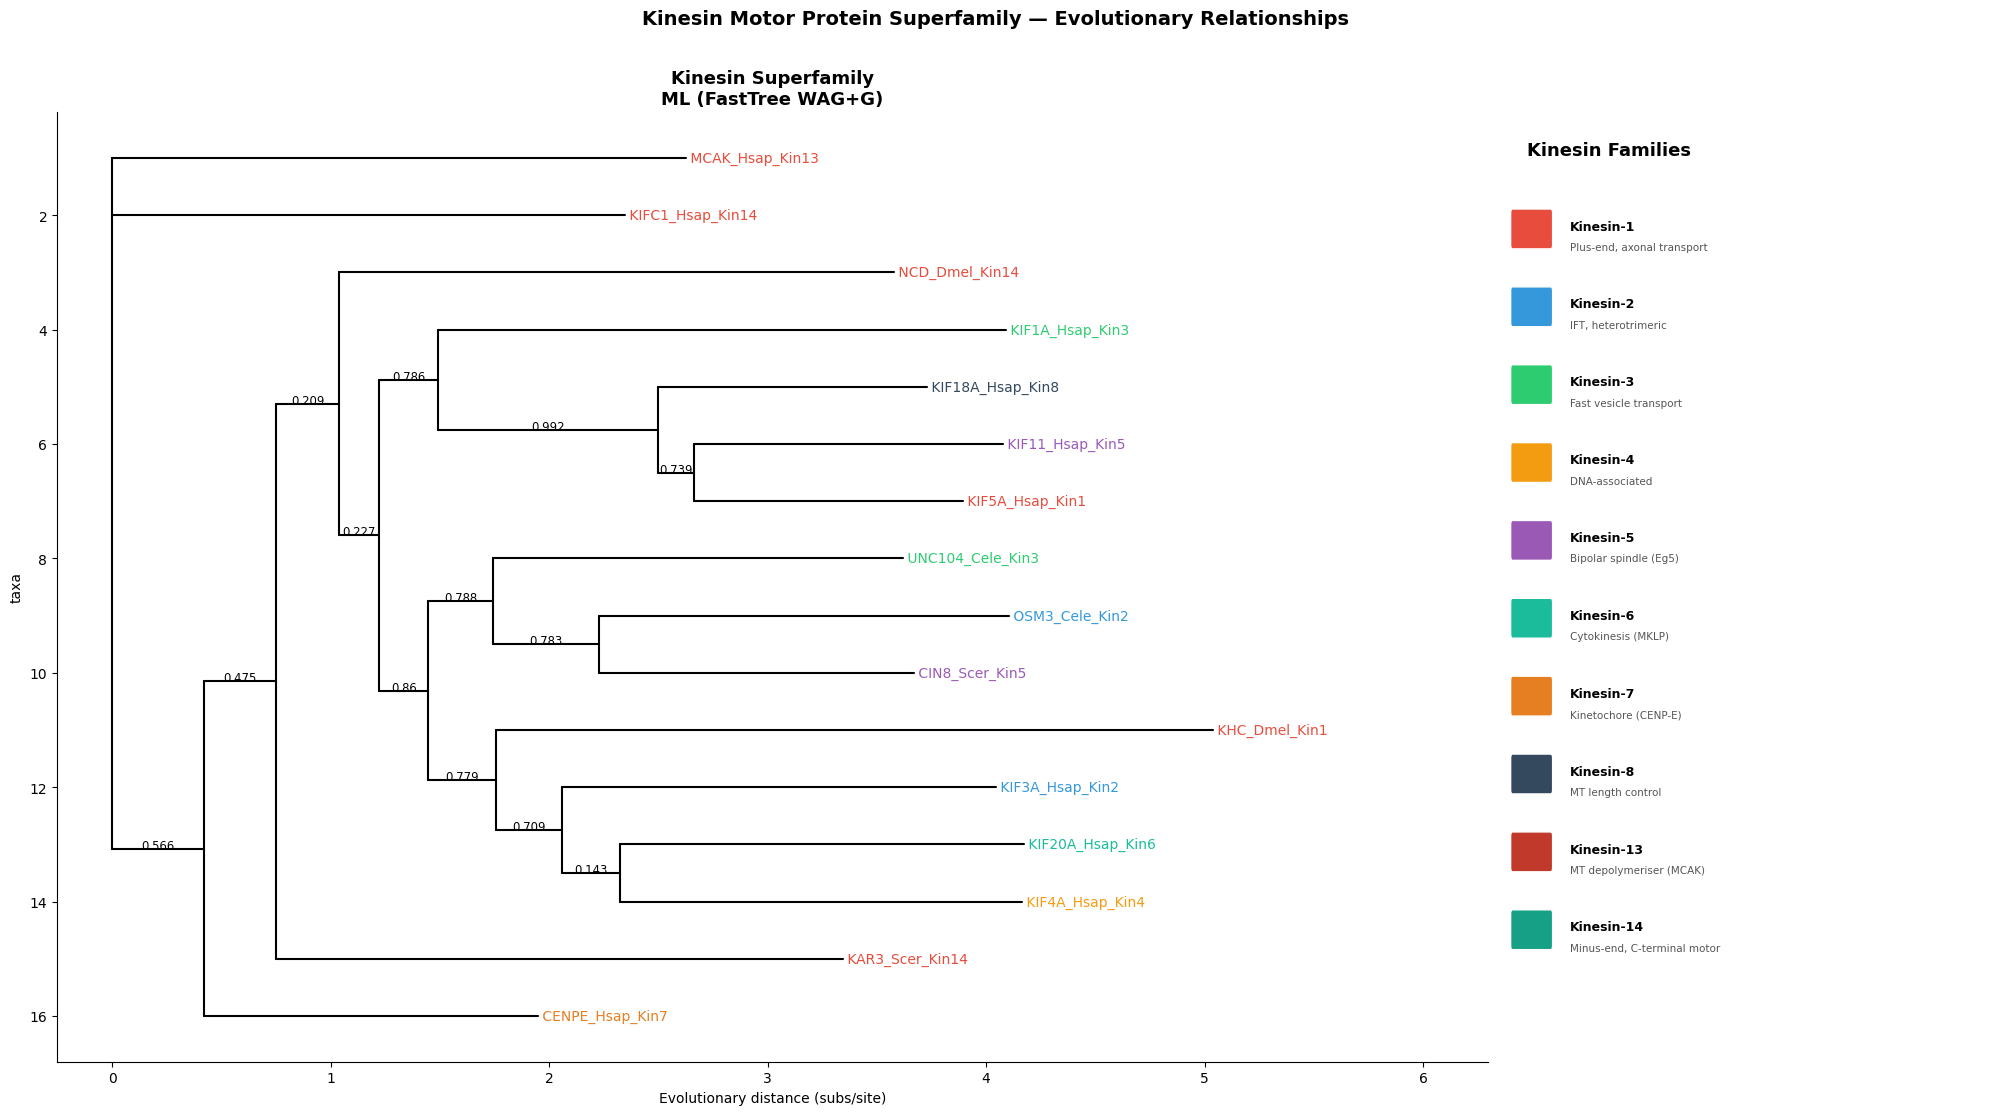

Figures saved.


In [9]:
FAM_COL = {
    'Kin1':'#E74C3C', 'Kin2':'#3498DB', 'Kin3':'#2ECC71',
    'Kin4':'#F39C12', 'Kin5':'#9B59B6', 'Kin6':'#1ABC9C',
    'Kin7':'#E67E22', 'Kin8':'#34495E', 'Kin13':'#C0392B', 'Kin14':'#16A085',
}
def tip_col(name):
    if not name: return 'black'
    for k, c in FAM_COL.items():
        if k in name: return c
    return '#aaa'

try:
    pt = Phylo.read('kin_ml.nwk', 'newick'); tree_lbl = 'ML (FastTree WAG+G)'
except Exception:
    pt = nj; tree_lbl = 'NJ (BLOSUM62)'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 11),
                                gridspec_kw={'width_ratios': [3, 1]})
Phylo.draw(pt, axes=ax1, do_show=False,
           label_func=lambda x: x.name if x.is_terminal() else '',
           label_colors=tip_col)
ax1.set_title(f'Kinesin Superfamily\n{tree_lbl}', fontsize=13, fontweight='bold')
ax1.set_xlabel('Evolutionary distance (subs/site)')
for s in ['top','right']: ax1.spines[s].set_visible(False)

ax2.axis('off')
ax2.text(0.05, 0.97, 'Kinesin Families', fontsize=13, fontweight='bold',
         transform=ax2.transAxes, va='top')
DESCS = [
    ('Kinesin-1','Kin1','Plus-end, axonal transport'),
    ('Kinesin-2','Kin2','IFT, heterotrimeric'),
    ('Kinesin-3','Kin3','Fast vesicle transport'),
    ('Kinesin-4','Kin4','DNA-associated'),
    ('Kinesin-5','Kin5','Bipolar spindle (Eg5)'),
    ('Kinesin-6','Kin6','Cytokinesis (MKLP)'),
    ('Kinesin-7','Kin7','Kinetochore (CENP-E)'),
    ('Kinesin-8','Kin8','MT length control'),
    ('Kinesin-13','Kin13','MT depolymeriser (MCAK)'),
    ('Kinesin-14','Kin14','Minus-end, C-terminal motor'),
]
y = 0.88
for full, key, desc in DESCS:
    col = FAM_COL.get(key, '#aaa')
    ax2.add_patch(mpatches.FancyBboxPatch((0.02, y-0.02), 0.08, 0.034,
        boxstyle='round,pad=0.004', facecolor=col, edgecolor='white',
        transform=ax2.transAxes))
    ax2.text(0.14, y, full, fontsize=9, fontweight='bold',
             transform=ax2.transAxes, va='center')
    ax2.text(0.14, y-0.022, desc, fontsize=7.5, color='#555',
             transform=ax2.transAxes, va='center')
    y -= 0.082

plt.suptitle('Kinesin Motor Protein Superfamily — Evolutionary Relationships',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('kin_phylogeny.pdf', dpi=150, bbox_inches='tight')
plt.savefig('kin_phylogeny.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figures saved.')

## Step 8 — Branch-length statistics

Tips:     16
Total BL: 36.8158
Mean BL:  1.26951   Max: 3.28050   Min: 0.16488


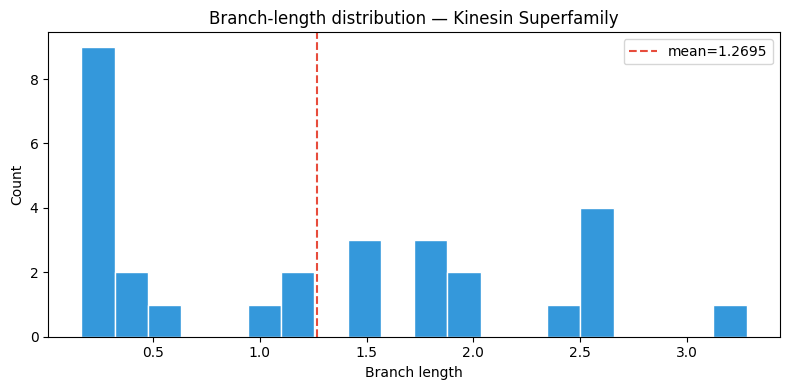

In [10]:
try: st = Phylo.read('kin_ml.nwk', 'newick')
except Exception: st = nj
bls = [c.branch_length for c in st.find_clades() if c.branch_length]
print(f'Tips:     {st.count_terminals()}')
print(f'Total BL: {st.total_branch_length():.4f}')
print(f'Mean BL:  {np.mean(bls):.5f}   Max: {max(bls):.5f}   Min: {min(bls):.5f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(bls, bins=20, color='#3498DB', edgecolor='white')
ax.axvline(np.mean(bls), color='#E74C3C', linestyle='--',
           label=f'mean={np.mean(bls):.4f}')
ax.set_xlabel('Branch length'); ax.set_ylabel('Count')
ax.set_title('Branch-length distribution — Kinesin Superfamily')
ax.legend(); plt.tight_layout()
plt.savefig('kin_bl_hist.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 9 — Download all results

In [11]:
from google.colab import files
import zipfile
outs = ['kin_raw.fasta','kin_aln.fasta','kin_trim.fasta',
        'kin_nj.nwk','kin_ml.nwk',
        'kin_phylogeny.pdf','kin_phylogeny.png','kin_bl_hist.png']
with zipfile.ZipFile('kinesin_results.zip', 'w') as zf:
    for f in outs:
        if os.path.exists(f): zf.write(f); print(f'  added {f}')
files.download('kinesin_results.zip')

  added kin_raw.fasta
  added kin_aln.fasta
  added kin_trim.fasta
  added kin_nj.nwk
  added kin_ml.nwk
  added kin_phylogeny.pdf
  added kin_phylogeny.png
  added kin_bl_hist.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>